We want to run some numerical simulations to test our multi atom theory.  The general prescription is
1) Find the eigenstates of each atom in the ensemble (maybe each velocity class instead?)
2) Calculate the combined eigenstates -> should be the tensor products of the eigenstates
3) Solve the master equation for the full density matrix steady state
4) Use the combined eigenstates to change the density matrix to the basis of eigenstates
5) Apply perturbation theory (I think this should just be to a linear combination of eigenstates using their populations as coefficients)

For extra clarity, I want to note that these simulations assume that the semiclassical lasers are co-propagating.  The counter-propagating case will be looked at in a different file.

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qu
import itertools as it

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Functions

In [3]:
def create_Hamiltonians(g10, g21, vels, f01=385e6, f02=625e6):
    """
    Function for creating a list of Hamiltonians.  Note that the only detuning is due to the Doppler affect
    :param g10:        the coupling strength between |0> and |1>
    :param g21:        the coupling strength between |1> and |2>
    :param vels:       array of velocities for the atoms for calculating Doppler shifts
    :param f01:        frequency of laser coupling |0> and |1> in MHz
    :param f02:        frequency of laser coupling |1> and |2> in MHz
    :returns:          a list of Hamiltonians
    """
    # Calculate the detunings for each atom
    Δ1s = f01 / 3e8 * vels
    Δ2s = f02 / 3e8 * vels

    # Now create the Hamiltonians
    Hs = [qu.Qobj(np.array([[0, g10, 0],
                            [g10, -_[0], g21],
                            [0, g21, -_[0]-_[1]]])) for _ in zip(Δ1s, Δ2s)]

    return Hs    

In [4]:
def create_cob_matrix(Hamiltonian_list):
    """
    Function for creating the change of basis matrix to change into the eigenbasis.  This requires calculating the eigenstates of the total
    Hamiltonian.  Because the total Hamiltonian is a Kronecker sum, the total eigenstates are just tensor products of the individual ones
    :param Hamiltonian_list:  the list of Hamiltonians
    :returns:                 the change of basis matrix
    """
    # Calculate the eigenstates
    eig_states = [_.eigenstates()[1] for _ in Hamiltonian_list]

    # Use itertools to get every combination of eigenstates
    eig_products = list(it.product(*eig_states))
    tens_list = [qu.tensor(_) for _ in eig_products]

    # Define the matrix that we'll fill in
    U = np.zeros((3 ** len(Hamiltonian_list), 3 ** len(Hamiltonian_list)), dtype=complex)

    # Now loop over the products and put them into the matrix
    for i in range(3 ** len(Hamiltonian_list)):
        U[i] = tens_list[i].full().T

    # Now create a Qobj from this matrix
    dim_list = [3 for _ in Hamiltonian_list]
    full_dims = [dim_list, dim_list]
    U = qu.Qobj(U.T, dims=full_dims)

    return U

In [5]:
def get_full_Hamiltonian(Hamiltonian_list):
    """
    Function for combining the individual Hamiltonians into the full system Hamiltonian.
    Example for two atoms: H = H0 \tensor I + I \tensor H1
    :param Hamiltonian_list:  the list of Hamiltonians to combine
    :returns:                 the full Hamiltonian
    """
    # Define the identity for ease of use
    I = qu.qeye(3)

    # Create list of identity tensor products
    id_list = [qu.qeye(3) for _ in Hamiltonian_list]

    # Define total Qobj with zeros for adding terms to
    dim_list = [3 for _ in Hamiltonian_list]
    full_dims = [dim_list, dim_list]
    tot_H = qu.Qobj(np.zeros((3**len(Hamiltonian_list), 3**len(Hamiltonian_list))), dims=full_dims)
    for i in range(len(Hamiltonian_list)):
        temp = id_list.copy()
        temp[i] = Hamiltonian_list[i]
        tot_H += qu.tensor(temp)

    return tot_H

In [6]:
def get_collapse_ops(num_atoms, γ, single_atom_op):
    """
    Function for calculating the Kronecker sum terms for the collapse operators given the operator for a single atom
    Example for two atoms: [γ * σ \tensor I, γ * I \tensor σ]
    :param num_atoms:         the number of atoms (determines number of elements in list)
    :param γ:                 the damping rate for the operator
    :param single_atom_op:    the operator as a quspin quantum object (Qobj)
    :returns:                 list of the terms in the Kronecker sum
    """
    # Define the identity for ease of use
    I = qu.qeye(3)

    # Create a list of identity tensor products
    id_list = [qu.qeye(3) for i in range(num_atoms)]

    # Create list for storing tensor products
    collapse_op_list = []
    for i in range(num_atoms):
        temp = id_list.copy()
        temp[i] = single_atom_op
        collapse_op_list.append(γ * qu.tensor(temp))

    return collapse_op_list   

### Single Atom Test Case
It's probably a good idea to include an example using a single atom for testing things out.  We'll assume that $g_{10} \gg g_{21}$ and that the atom is motionless to start with.  This means that we should get the atom ends up essentially entirely in the dark state.

In [7]:
# Define parameters
g10 = 50
g21 = 10
vel = np.zeros(1)

In [8]:
# Define the Hamiltonian and calculate eigenstates
H = create_Hamiltonians(g10, g21, vel)[0]
H.eigenstates()

(array([-5.09901951e+01,  7.81597009e-14,  5.09901951e+01]),
 array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.69337525]
         [-0.70710678]
         [ 0.13867505]]                                                       ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[-1.96116135e-01]
         [-2.50828011e-16]
         [ 9.80580676e-01]]                                                   ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.69337525]
         [0.70710678]
         [0.13867505]]                                                        ],
       dtype=object))

In [9]:
# Define collapse operators
σ10 = qu.Qobj(np.array([[0, 1, 0],
                        [0, 0, 0],
                        [0, 0, 0]]))
σ21 = qu.Qobj(np.array([[0, 0, 0],
                        [0, 0, 1],
                        [0, 0, 0]]))

# Define decay rates
γ10 = 1
γ21 = 0.05

In [10]:
# Get lists of collapse operators for the steady state solver
σ10_list = get_collapse_ops(1, γ10, σ10)
σ21_list = get_collapse_ops(1, γ21, σ21)

In [11]:
# Caculate the steady state density matrix in the atomic energy level basis
ρ_ss = qu.steadystate(H, [γ10 * σ10, γ21 * σ21])
ρ_ss

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.08761211+0.j          0.        +0.00055555j -0.16025655+0.j        ]
 [ 0.        -0.00055555j  0.05555525+0.j          0.        +0.0001071j ]
 [-0.16025655-0.j          0.        -0.0001071j   0.85683264+0.j        ]]

In [12]:
test_ρ_ss = qu.steadystate(H, [*σ10_list, *σ21_list])
test_ρ_ss

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.08761211+0.j          0.        +0.00055555j -0.16025655+0.j        ]
 [ 0.        -0.00055555j  0.05555525+0.j          0.        +0.0001071j ]
 [-0.16025655-0.j          0.        -0.0001071j   0.85683264+0.j        ]]

In [13]:
# Check that the expectation values give us the population in the states |0>, |1>, and |2>
# These should be the diagonal elements of ρ_ss
p0 = qu.expect(σ10 * σ10.dag(), ρ_ss)
print("Probability of being in |0>: ", p0)
p1 = qu.expect(σ10.dag() * σ10, ρ_ss)
print("Probability of being in |1>: ", p1)
p2 = qu.expect(σ21.dag() * σ21, ρ_ss)
print("Probability of being in |2>: ", p2)

Probability of being in |0>:  0.08761211291388767
Probability of being in |1>:  0.05555524691529479
Probability of being in |2>:  0.8568326401708174


In [14]:
U = create_cob_matrix([H])

In [15]:
# Check that U diagonalizes the Hamiltonian
# This also tells us how the eigenstates map to the computational basis
U.dag() * H * U

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-5.09901951e+01 -2.22044605e-14 -1.77635684e-14]
 [-2.16044722e-14 -8.67746996e-30  3.51700711e-15]
 [-1.72084569e-14  3.55271368e-15  5.09901951e+01]]

In [16]:
# Transform the density matrix to the eigenbasis of H
ρ_eig_ss = U.dag() * ρ_ss * U
ρ_eig_ss

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 5.55578146e-02-1.52465931e-20j -1.48548404e-06-1.51304584e-04j
   2.56768318e-06+5.23759177e-04j]
 [-1.48548404e-06+1.51304584e-04j  8.88884371e-01+0.00000000e+00j
  -1.48548404e-06-1.51304584e-04j]
 [ 2.56768318e-06-5.23759177e-04j -1.48548404e-06+1.51304584e-04j
   5.55578146e-02-7.11507676e-20j]]

So we see that the atom is most likely to be in the dark state, which is what we expected for this configuration.  How does this change if we change the velocity of the atom so that it is very far off resonance?

In [17]:
# Redefine the velocity - we'll use the rms velocity for now
vel = np.array([300])

In [18]:
# Define the Hamiltonian and calculate eigenstates
H = create_Hamiltonians(g10, g21, vel)[0]

Notice that the eigenstates are basically $|2\rangle$, $|1\rangle$, and $|0\rangle$ in this case.

In [19]:
# Caculate the steady state density matrix in the atomic energy level basis - using same collapse operators as before
ρ_ss = qu.steadystate(H, [γ10 * σ10, γ21 * σ21])
ρ_ss

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[9.83670777e-01+0.00000000e+00j 1.25661365e-01+1.63238597e-04j
  1.23614200e-03+1.61772042e-06j]
 [1.25661365e-01-1.63238597e-04j 1.63238597e-02+0.00000000e+00j
  1.62204578e-04+6.70438188e-10j]
 [1.23614200e-03-1.61772042e-06j 1.62204578e-04-6.70438188e-10j
  5.36350550e-06+0.00000000e+00j]]

In [20]:
# Generate the change of basis matrix from the Hamiltonian eigenstates - note that there's probably a more pythonic way to do this
U = create_cob_matrix([H])

In [21]:
# Check that U diagonalizes the Hamiltonian
# This also tells us how the eigenstates map to the computational basis
U.dag() * H * U

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.01016059e+03 -1.42108547e-14 -2.22044605e-16]
 [-1.33226763e-14 -3.91228517e+02  1.62266034e-14]
 [-4.63171168e-16  2.58334207e-14  6.38911134e+00]]

In [22]:
# Transform the density matrix to the eigenbasis of H
ρ_eig_ss = U.dag() * ρ_ss * U
ρ_eig_ss

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 3.74119287e-06+6.20385459e-25j -1.64577908e-10+8.12437610e-10j
   1.28493031e-09+1.01193999e-06j]
 [-1.64577908e-10-8.12437610e-10j  2.66665068e-04+2.72225140e-21j
  -2.05244377e-07-1.63243476e-04j]
 [ 1.28493031e-09-1.01193999e-06j -2.05244377e-07+1.63243476e-04j
   9.99729594e-01+9.64492594e-22j]]

From the steady state density matrix in the atomic energy level basis, we can see that the atom is most likely to be in the ground state $|0\rangle$.  This corresponds to the eigenstate of the Hamiltonian with eigenvalue 6.389, which makes sense given that that eigenstate is essentially just the ground state anyway.  This lines up with the results that we were seeing in our other simulations.  As an additional note, I'm not sure if we can really label any of these eigenstates as bright or dark.  Also, the eigenstates for this Hamiltonian are different, so I think we have to be careful comparing this matrix to the one we obtained when the atom had zero velocity.

### 2 Atoms
Now that we've confirmed that the approach seems to work for one atom, let's add another atom.  For the detuning variables, we'll use two subscripts.  The first will define the atom that it applies to, while the second denotes which laser the detuning is defined with respect to.  We'll start with two motionless atoms, and then we'll let one move.

In [23]:
# Define the velocities of the atoms
vels = np.zeros(2)

In [24]:
# Get the Hamiltonians
H_list = create_Hamiltonians(g10, g21, vels)

In [25]:
# Get the full Hamiltonian
H = get_full_Hamiltonian(H_list)

In [26]:
# Get the matrix that changes the basis to the eigenbasis of the full Hamiltonian
U = create_cob_matrix(H_list)

In [27]:
# Check that this diagonalizes the full hamiltonian
U.dag() @ H @ U

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.01980390e+02 -1.99285033e-14 -2.02546313e-14 -1.91513472e-14
   0.00000000e+00  5.55111512e-16 -1.90333860e-14  4.99600361e-16
   1.29063427e-15]
 [-2.26207941e-14 -5.09901951e+01  5.88418203e-15  0.00000000e+00
  -2.22044605e-14 -2.22044605e-16  9.43689571e-16 -1.45439216e-14
   1.11022302e-16]
 [-1.88798020e-14  5.01287313e-15 -1.19626110e-15 -1.69971435e-16
   1.28102657e-16 -2.11470531e-14  1.06815845e-15  4.76556378e-17
  -2.25485972e-14]
 [-2.24542607e-14 -1.11022302e-16  1.19348975e-15 -5.09901951e+01
  -2.30926389e-14 -1.37667655e-14  5.19029264e-15 -1.11022302e-16
  -5.55111512e-17]
 [-2.17732649e-16 -2.18224319e-14  2.53914604e-30 -2.18224319e-14
  -1.89326617e-29  3.73496673e-15 -8.13512809e-31  3.73496673e-15
   2.17732649e-16]
 [ 1.52655666e-15  1.11022302e-16 -2.03448369e-14 -1.76525461e-14
   3.55271368e-15  5.09901951e+01  8.32667268e-17  1.11022302e-16
   0.00000

In [28]:
# Define the collapse operators
σ10_list = get_collapse_ops(2, γ10, σ10)
σ21_list = get_collapse_ops(2, γ21, σ21)

In [29]:
# Caculate the steady state density matrix in the atomic energy level basis - using same collapse operators as before
ρ_ss = qu.steadystate(H, [*σ10_list, *σ21_list])
ρ_ss

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 7.67588233e-03+0.00000000e+00j  0.00000000e+00+4.86731257e-05j
  -1.40404152e-02-0.00000000e+00j  0.00000000e+00+4.86731257e-05j
  -3.08638546e-07+0.00000000e+00j  0.00000000e+00-8.90309234e-05j
  -1.40404152e-02+0.00000000e+00j  0.00000000e+00-8.90309234e-05j
   2.56821626e-02+0.00000000e+00j]
 [ 0.00000000e+00-4.86731257e-05j  4.86731257e-03+0.00000000e+00j
   0.00000000e+00+9.38361475e-06j  3.08638546e-07+0.00000000e+00j
   0.00000000e+00+3.08638546e-05j -5.95019362e-08+0.00000000e+00j
   0.00000000e+00+8.90309234e-05j -8.90309234e-03+0.00000000e+00j
   0.00000000e+00-1.71641306e-05j]
 [-1.40404152e-02+0.00000000e+00j  0.00000000e+00-9.38361475e-06j
   7.50689180e-02+0.00000000e+00j  0.00000000e+00-8.90309234e-05j
   5.95019361e-08+0.00000000e+00j  0.00000000e+00+4.76015489e-04j
   2.56821626e-02+0.00000000e+00j  0.00000000e+00+1.71641306e-05j
  -1.37313045e-01+0.00000000e+00j]


In [30]:
# Transform the density matrix to the eigenbasis of H
ρ_eig_ss = U.dag() * ρ_ss * U
ρ_eig_ss

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 3.08667076e-03-3.47415857e-21j -8.25302468e-08-8.40615201e-06j
   1.42654866e-07+2.90989153e-05j -8.25302468e-08-8.40615201e-06j
  -2.28908704e-08+4.49521089e-10j  7.92433500e-08-1.16653813e-09j
   1.42654866e-07+2.90989153e-05j  7.92433500e-08-1.16653813e-09j
  -2.74317083e-07+2.68969527e-09j]
 [-8.25302468e-08+8.40615201e-06j  4.93844731e-02+7.62329653e-20j
  -8.25302468e-08-8.40615201e-06j  2.28952839e-08+3.81003890e-16j
  -1.32042354e-06-1.34492280e-04j -2.28908704e-08+4.49521089e-10j
  -7.92509785e-08-3.89533670e-10j  2.28237345e-06+4.65561347e-04j
   7.92433500e-08-1.16653813e-09j]
 [ 1.42654866e-07-2.90989153e-05j -8.25302468e-08+8.40615201e-06j
   3.08667076e-03+3.18451810e-21j -7.92509785e-08+3.89533662e-10j
   2.28952838e-08-8.59200804e-16j -8.25302468e-08-8.40615201e-06j
   2.74330269e-07-2.69858263e-17j -7.92509785e-08-3.89533670e-10j
   1.42654866e-07+2.90989153e-05j]


(array([-5.09901951e+01,  7.81597009e-14,  5.09901951e+01]), array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[ 0.69337525]
        [-0.70710678]
        [ 0.13867505]]                                                       ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[-1.96116135e-01]
        [-2.50828011e-16]
        [ 9.80580676e-01]]                                                   ,
       Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
       Qobj data =
       [[0.69337525]
        [0.70710678]
        [0.13867505]]                                                        ],
      dtype=object))


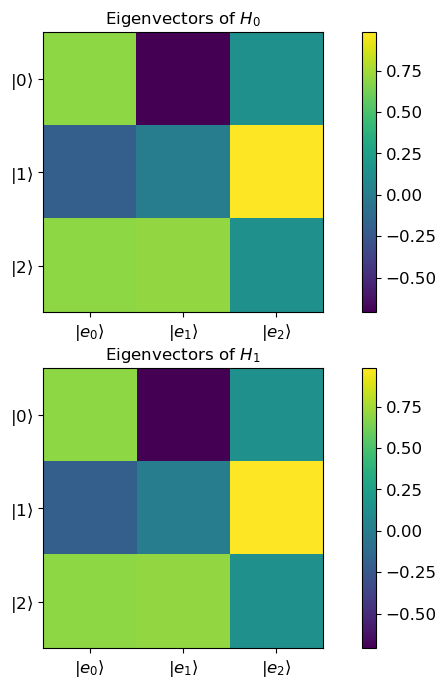

In [31]:
# Let's also plot the two sets of eigenvectors for completeness
# First get eigenvectors of each Hamiltonian into 2d arrays
H0_eigs = np.array([_.full() for _ in H_list[0].eigenstates()[1]])
print(H_list[0].eigenstates())
H1_eigs = np.array([_.full() for _ in H_list[1].eigenstates()[1]])

# Now plot
fig = plt.figure(1, figsize=(10, 8))
ax = fig.subplots(2, 1)
h0 = ax[0].imshow(H0_eigs.real)
ax[0].set_title("Eigenvectors of $H_0$")
ax[0].set_xticks([0, 1, 2])
ax[0].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[0].set_yticks([0, 1, 2])
ax[0].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h0)

h1 = ax[1].imshow(H1_eigs.real)
ax[1].set_title("Eigenvectors of $H_1$")
ax[1].set_xticks([0, 1, 2])
ax[1].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h1)

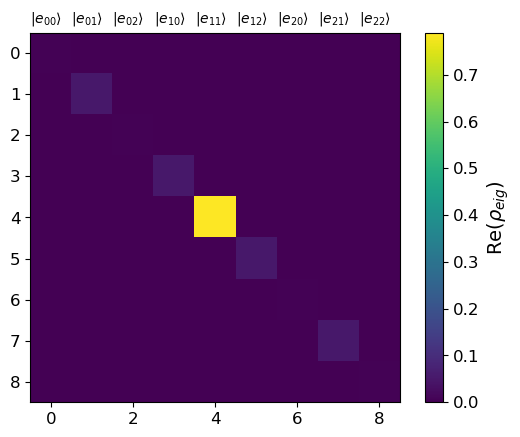

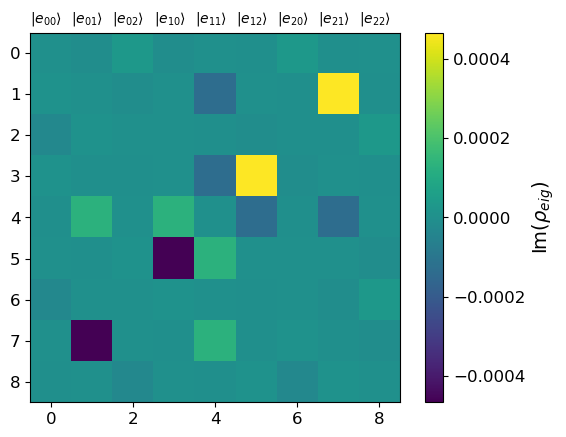

In [32]:
# Generate labels for trying to keep track of the eigenstates
labels = [["$|e_{" + str(j) + str(i) + "}\\rangle$" for i in range(3)] for j in range(3)]

# Now plot the real and imaginary parts of the density matrix in the eigenbasis
plt.figure(1)
plt.imshow(ρ_eig_ss.full().real)
plt.colorbar(label='$\\mathrm{Re}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        plt.text(-0.5 + count, -0.75, labels[i][j], size=10)
        count += 1

plt.figure(2)
plt.imshow(ρ_eig_ss.full().imag)
plt.colorbar(label='$\\mathrm{Im}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        plt.text(-0.5 + count, -0.75, labels[i][j], size=10)
        count += 1

plt.show()

So we see from the density matrix in the atomic energy level basis that the highest probability state is when both atoms are in the Rydberg state, which is what we expected for two motionless atoms.  When we change the basis, the largest probability state is the eigenstate with the lowest eigenvalue i.e. both atoms in the dark state.  From this, it seems that this method works pretty well.  I will need to consider how to generalize it algorithmically to more atoms.  For now, the next step is going to be to change the velocity of the second and see how things change.  I also want to see how things change if we use collective operators for atoms that have the same speed.

Now what if one of the atoms has a large velocity and the other is motionless?

In [33]:
# Define the velocities
vels = np.array([0, 300])

In [34]:
# Get the Hamiltonians
H_list = create_Hamiltonians(g10, g21, vels)

In [35]:
# Get the full Hamiltonian
H = get_full_Hamiltonian(H_list)

In [36]:
# Calculate change of basis matrix
U = create_cob_matrix(H_list)

In [37]:
# Check that this diagonalizes the full hamiltonian
U.dag() @ H @ U

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.06115079e+03 -1.27675648e-14 -5.65519853e-16 -2.84217094e-14
   0.00000000e+00  2.77555756e-17 -8.52651283e-14 -3.33066907e-16
  -2.32452946e-16]
 [-1.31838984e-14 -4.42218712e+02  1.93425191e-14 -9.99200722e-16
  -2.71484224e-15  1.39992185e-15  1.44328993e-15 -6.08380533e-14
   6.46349836e-15]
 [-5.00034042e-16  2.05778218e-14 -4.46010838e+01 -1.47451495e-17
   9.91340256e-16 -2.35497843e-14  3.40439482e-17 -1.80709058e-15
  -1.75118997e-14]
 [-2.84217094e-14 -4.44089210e-16  0.00000000e+00 -1.01016059e+03
  -1.42108547e-14 -2.22044605e-16  5.68434189e-14  0.00000000e+00
   2.77555756e-17]
 [-2.22044605e-16 -1.06772230e-14  1.11694508e-15 -1.42108547e-14
  -3.91228517e+02  2.21576230e-14 -2.22044605e-16  1.77097920e-14
   2.25947733e-16]
 [ 1.21430643e-17 -2.76905235e-16 -2.03684658e-14 -3.38271078e-16
   2.17748725e-14  6.38911134e+00  1.23599048e-17 -1.31832208e-17
   2.09447

In [38]:
# Caculate the steady state density matrix in the atomic energy level basis - using same collapse operators as before
ρ_ss = qu.steadystate(H, [*σ10_list, *σ21_list])
ρ_ss

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 8.61814752e-02+0.00000000e+00j  1.10094577e-02+1.43016784e-05j
   1.08301013e-04+1.41731904e-07j  4.21167802e-16+5.46480729e-04j
  -9.06876056e-08+6.98114818e-05j -8.98728574e-10+6.86741742e-07j
  -1.57639687e-01+1.53052113e-18j -2.01380572e-02-2.61600548e-05j
  -1.98099856e-04-2.59250298e-07j]
 [ 1.10094577e-02-1.43016784e-05j  1.43016784e-03+0.00000000e+00j
   1.42110858e-05+5.87385062e-11j  9.06876057e-08+6.98114818e-05j
  -7.45537455e-17+9.06876057e-06j -3.72465180e-13+9.01131541e-08j
  -2.01380572e-02+2.61600548e-05j -2.61600548e-03-3.37231168e-19j
  -2.59943465e-05-1.07442113e-10j]
 [ 1.08301013e-04-1.41731904e-07j  1.42110858e-05-5.87385062e-11j
   4.69908050e-07+0.00000000e+00j  8.98728576e-10+6.86741742e-07j
   3.72462559e-13+9.01131541e-08j  8.97254577e-19+2.97970872e-09j
  -1.98099856e-04+2.59250298e-07j -2.59943465e-05+1.07442113e-10j
  -8.59536900e-07-1.88800688e-21j]


In [39]:
# Transform the density matrix to the eigenbasis of H
ρ_eig_ss = U.dag() * ρ_ss * U
ρ_eig_ss

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 2.07852500e-07-1.29246971e-25j -9.14358867e-12+4.51372582e-11j
   7.13879200e-11+5.62211743e-08j -5.55748228e-12-5.66059630e-10j
   1.23169903e-13+2.36945334e-14j  1.53109250e-10-1.69763654e-12j
   9.60619796e-12+1.95948410e-09j -4.25944384e-13-8.41131080e-14j
  -5.30009557e-10+3.27133532e-12j]
 [-9.14358867e-12-4.51372582e-11j  1.48153284e-05-1.24933111e-21j
  -1.14029291e-08-9.06945079e-06j -1.22681007e-13+2.61082741e-14j
  -3.96126623e-10-4.03476472e-08j -2.46991813e-08+2.73549993e-10j
   4.25098406e-13-8.82852992e-14j  6.84711335e-10+1.39668277e-07j
   8.54997419e-08-5.26656154e-10j]
 [ 7.13879200e-11-5.62211743e-08j -1.14029291e-08+9.06945079e-06j
   5.55427914e-02-1.00322565e-20j -1.53113067e-10+1.30880486e-12j
   2.46997911e-08-2.11441163e-10j -1.48508235e-06-1.51263670e-04j
   5.30016156e-10-1.92534726e-12j -8.55007959e-08+3.11658902e-10j
   2.56698886e-06+5.23617550e-04j]


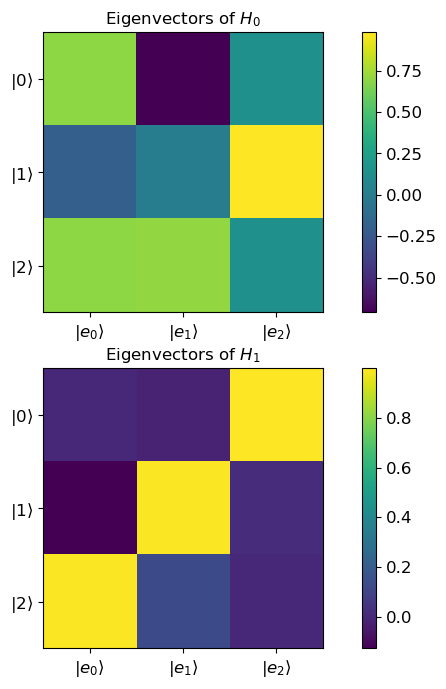

In [40]:
# Let's also plot the two sets of eigenvectors for completeness
# First get eigenvectors of each Hamiltonian into 2d arrays
H0_eigs = np.array([_.full() for _ in H_list[0].eigenstates()[1]])
H1_eigs = np.array([_.full() for _ in H_list[1].eigenstates()[1]])

# Now plot
fig = plt.figure(1, figsize=(10, 8))
ax = fig.subplots(2, 1)
h0 = ax[0].imshow(H0_eigs.real)
ax[0].set_title("Eigenvectors of $H_0$")
ax[0].set_xticks([0, 1, 2])
ax[0].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[0].set_yticks([0, 1, 2])
ax[0].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h0)

h1 = ax[1].imshow(H1_eigs.real)
ax[1].set_title("Eigenvectors of $H_1$")
ax[1].set_xticks([0, 1, 2])
ax[1].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h1)

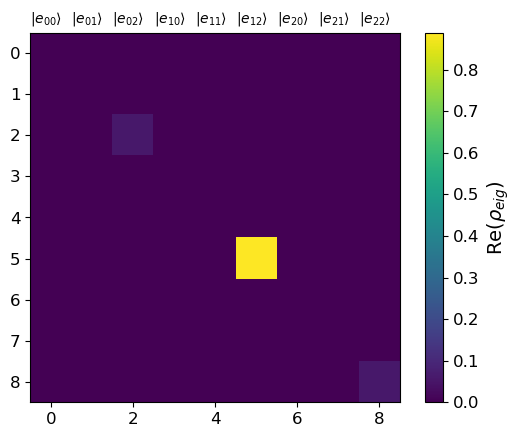

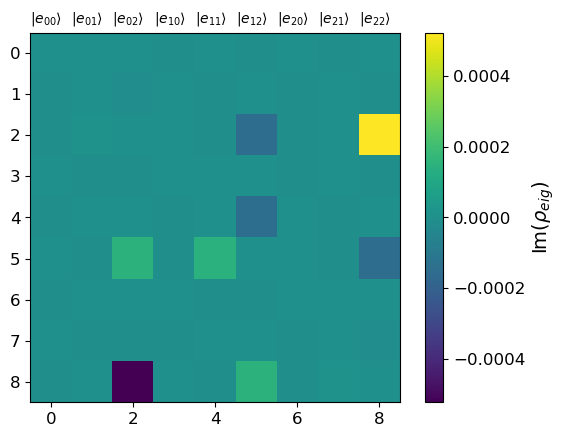

In [41]:
# Generate labels for trying to keep track of the eigenstates
labels = [["$|e_{" + str(j) + str(i) + "}\\rangle$" for i in range(3)] for j in range(3)]

# Now plot the real and imaginary parts of the density matrix in the eigenbasis
plt.figure(1)
plt.imshow(ρ_eig_ss.full().real)
plt.colorbar(label='$\\mathrm{Re}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        plt.text(-0.5 + count, -0.75, labels[i][j], size=10)
        count += 1

plt.figure(2)
plt.imshow(ρ_eig_ss.full().imag)
plt.colorbar(label='$\\mathrm{Im}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        plt.text(-0.5 + count, -0.75, labels[i][j], size=10)
        count += 1

plt.show()

So the most probable steady state is when the motionless atom is in the dark state (effectively the Rydberg state given the parameters we're using) and the moving atom is in its ground state.  This is not particularly surprising given our single atom test calculations.

What happens if both atoms are moving in opposite directions at $v_{rms}$?  My expectation is that the most probable state will be both atoms in the ground state given that they should both be far off resonance.

In [42]:
# Define velocities
vels = np.array([300, -300])

In [43]:
# Create list of Hamiltonians
H_list = create_Hamiltonians(g10, g21, vels)

In [44]:
# Get the total Hamiltonian
H = get_full_Hamiltonian(H_list)

In [45]:
# Calculate the matrix that changes into Hamiltonian eigenbasis
U = create_cob_matrix(H_list)

In [46]:
# Check that this diagonalizes the full hamiltonian
U.dag() @ H @ U

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.01654971e+03  1.57058394e-13  0.00000000e+00 -1.30811398e-14
  -1.28694798e-16  3.46944695e-18 -4.16240037e-16 -4.72102283e-17
  -8.67361738e-19]
 [ 1.51623505e-13 -6.18932078e+02 -1.77635684e-15  2.57931697e-16
  -1.40282751e-14  0.00000000e+00  2.07861885e-17 -3.69225050e-16
   8.67361738e-18]
 [ 1.23772186e-16 -1.77191670e-15 -2.28697952e-17  2.81639566e-18
  -2.27267628e-17 -1.07440900e-14  1.43032404e-19 -2.08763820e-18
  -2.96593264e-17]
 [-1.08538277e-14  3.90719358e-16  1.73472348e-18 -3.97617628e+02
   1.12771047e-13 -5.54840462e-17  2.03548290e-14  3.01622265e-16
  -6.93719984e-18]
 [ 4.19748055e-17 -1.30403310e-14  3.74216608e-17  1.14988970e-13
  -4.86847882e-16 -3.33968660e-15 -5.24269543e-16  4.13339605e-14
  -1.92131204e-16]
 [ 1.73472348e-18  8.32667268e-17 -1.42108547e-14  3.33094012e-16
  -3.55358104e-15  6.18932078e+02  4.16367516e-17 -6.66160920e-16
   8.34592

In [47]:
# Calculate the steady state density matrix in the atomic energy level basis
ρ_ss = qu.steadystate(H, [*σ10_list, *σ21_list])

In [48]:
# Transform the density matrix to the eigenbasis of H
ρ_eig_ss = U.dag() * ρ_ss * U
ρ_eig_ss

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 3.74018123e-06+5.36417527e-25j  7.67858810e-13+6.10725330e-10j
   4.80717214e-15+3.78586267e-12j -1.64533405e-10+8.12217921e-10j
  -1.32658874e-13-2.66995148e-14j -8.22351362e-16-1.65499066e-16j
   1.28458286e-09+1.01166635e-06j -1.65192338e-10+4.17451487e-13j
  -1.02402089e-12+2.60054473e-15j]
 [ 7.67858810e-13-6.10725330e-10j  9.97645453e-10+7.77027992e-27j
   6.15717692e-16-3.03948579e-15j  1.32592398e-13+2.70330157e-14j
  -4.38871679e-14+2.16648732e-13j  6.33340772e-19+2.67415482e-19j
   1.65192865e-10-2.06149319e-15j  3.42646576e-13+2.69849046e-10j
   8.22346113e-16+1.65499033e-16j]
 [ 4.80717214e-15-3.78586267e-12j  6.15717693e-16+3.03948579e-15j
   1.39965242e-11+1.56431932e-30j  8.21923229e-16+1.67587899e-16j
  -6.89358683e-19-1.04969296e-18j -6.15761643e-16+3.03948578e-15j
   1.02402779e-12-6.78750989e-17j -8.21916308e-16+1.67587096e-16j
   4.80748015e-15+3.78586267e-12j]


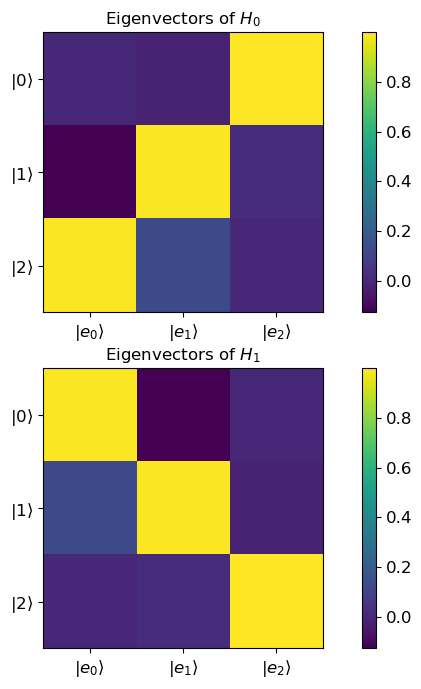

In [49]:
# Let's also plot the two sets of eigenvectors for completeness
# First get eigenvectors of each Hamiltonian into 2d arrays
H0_eigs = np.array([_.full() for _ in H_list[0].eigenstates()[1]])
H1_eigs = np.array([_.full() for _ in H_list[1].eigenstates()[1]])

# Now plot
fig = plt.figure(1, figsize=(10, 8))
ax = fig.subplots(2, 1)
h0 = ax[0].imshow(H0_eigs.real)
ax[0].set_title("Eigenvectors of $H_0$")
ax[0].set_xticks([0, 1, 2])
ax[0].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[0].set_yticks([0, 1, 2])
ax[0].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h0)

h1 = ax[1].imshow(H1_eigs.real)
ax[1].set_title("Eigenvectors of $H_1$")
ax[1].set_xticks([0, 1, 2])
ax[1].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h1)

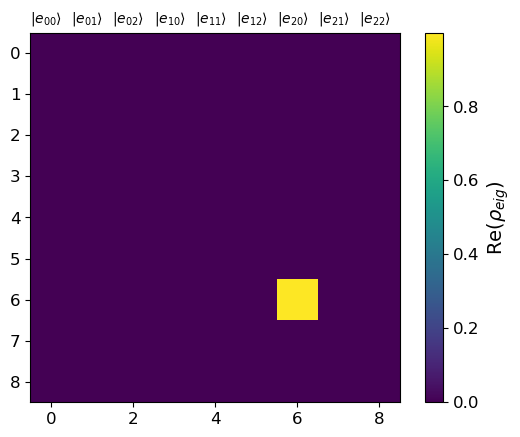

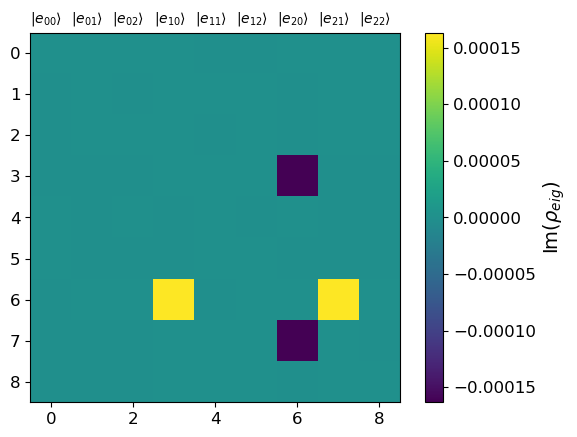

In [50]:
# Generate labels for trying to keep track of the eigenstates
labels = [["$|e_{" + str(j) + str(i) + "}\\rangle$" for i in range(3)] for j in range(3)]

# Now plot the real and imaginary parts of the density matrix in the eigenbasis
plt.figure(1)
plt.imshow(ρ_eig_ss.full().real)
plt.colorbar(label='$\\mathrm{Re}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        plt.text(-0.5 + count, -0.75, labels[i][j], size=10)
        count += 1

plt.figure(2)
plt.imshow(ρ_eig_ss.full().imag)
plt.colorbar(label='$\\mathrm{Im}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        plt.text(-0.5 + count, -0.75, labels[i][j], size=10)
        count += 1

plt.show()

As I expected, the most probable steady state is that both atoms are in the ground state (as seen from $\rho_{00}=0.968$ when the density matrix is expressed in the atomic energy level basis.  In the eigenbasis, this corresponds to atom 0 being in its third eigenstate and atom 1 being in its first, so $\rho_{77}=0.999$.

Now what if one atom is moving at say only 10 m/s and the other is motionless?  This should help give us an idea of what we should see if its not in between those two extremes.

In [51]:
# Define velocities
vels = np.array([0, 10])

In [52]:
# Create list of Hamiltonians
H_list = create_Hamiltonians(g10, g21, vels)

In [53]:
# Get the total Hamiltonian
H = get_full_Hamiltonian(H_list)

In [54]:
# Calculate the matrix that changes into Hamiltonian eigenbasis
U = create_cob_matrix(H_list)

In [55]:
# Check that this diagonalizes the full hamiltonian
U.dag() @ H @ U

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.10072215e+02 -6.16173779e-14 -2.43485787e-14 -2.24265051e-14
  -8.88178420e-16 -3.05311332e-15 -1.92068583e-14  2.33146835e-15
  -5.83560977e-15]
 [-6.69464484e-14 -8.29633990e+01  9.02056208e-15  1.33226763e-15
  -1.95399252e-14  6.66133815e-16 -2.99760217e-15 -2.48689958e-14
  -3.05311332e-16]
 [-1.97558983e-14  7.36043171e-15 -6.43497096e+00  1.38777878e-17
   1.38777878e-17 -2.11662285e-14 -1.47451495e-16  3.08780779e-16
  -2.46605037e-14]
 [-1.98729921e-14  0.00000000e+00 -1.11022302e-16 -5.90820203e+01
  -6.21724894e-14 -1.86517468e-14  5.99520433e-15 -4.44089210e-16
  -6.38378239e-16]
 [ 6.66133815e-16 -2.04281037e-14  2.22044605e-16 -6.03961325e-14
  -3.19732039e+01  7.54951657e-15  2.22044605e-16  4.88498131e-15
  -1.11022302e-16]
 [-1.88737914e-15  9.99200722e-16 -2.09277040e-14 -2.26485497e-14
   6.66133815e-15  4.45552242e+01 -1.66533454e-16 -1.11022302e-16
   1.39471

In [56]:
# Calculate the steady state density matrix in the atomic energy level basis
ρ_ss = qu.steadystate(H, [*σ10_list, *σ21_list])

In [57]:
# Transform the density matrix to the eigenbasis of H
ρ_eig_ss = U.dag() * ρ_ss * U
ρ_eig_ss

Quantum object: dims=[[3, 3], [3, 3]], shape=(9, 9), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 9.45034283e-03+9.98572435e-21j -2.51543500e-07+8.58483184e-06j
   5.98742245e-07+1.18691852e-04j -2.52679727e-07-2.57367969e-05j
   2.33864143e-08+4.55508444e-10j  3.23226029e-07-4.80413600e-09j
   4.36760994e-07+8.90910455e-05j -8.09432549e-08-1.97461128e-09j
  -1.11891387e-06+1.11300241e-08j]
 [-2.51543500e-07-8.58483184e-06j  2.95372044e-02-2.87991202e-20j
  -2.60723272e-07-6.44016528e-05j -2.33729630e-08+9.14584490e-10j
  -7.89754710e-07-8.04407886e-05j -1.75382672e-07+2.43199367e-09j
   8.09200040e-08-2.76813164e-09j  1.36510378e-06+2.78455551e-04j
   6.07120483e-07-5.43432545e-09j]
 [ 5.98742245e-07-1.18691852e-04j -2.60723272e-07+6.44016528e-05j
   1.65702673e-02+2.63738267e-20j -3.23258047e-07+1.54294056e-09j
   1.75396614e-07-1.01190088e-09j -4.43049602e-07-4.51269982e-05j
   1.11896921e-06+1.58999113e-10j -6.07144582e-07+5.18501921e-10j
   7.65818400e-07+1.56212580e-04j]


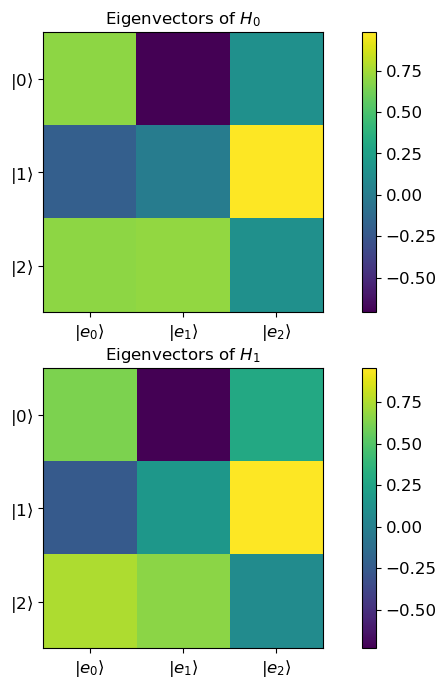

In [58]:
# Let's also plot the two sets of eigenvectors for completeness
# First get eigenvectors of each Hamiltonian into 2d arrays
H0_eigs = np.array([_.full() for _ in H_list[0].eigenstates()[1]])
H1_eigs = np.array([_.full() for _ in H_list[1].eigenstates()[1]])

# Now plot
fig = plt.figure(1, figsize=(10, 8))
ax = fig.subplots(2, 1)
h0 = ax[0].imshow(H0_eigs.real)
ax[0].set_title("Eigenvectors of $H_0$")
ax[0].set_xticks([0, 1, 2])
ax[0].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[0].set_yticks([0, 1, 2])
ax[0].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h0)

h1 = ax[1].imshow(H1_eigs.real)
ax[1].set_title("Eigenvectors of $H_1$")
ax[1].set_xticks([0, 1, 2])
ax[1].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h1)

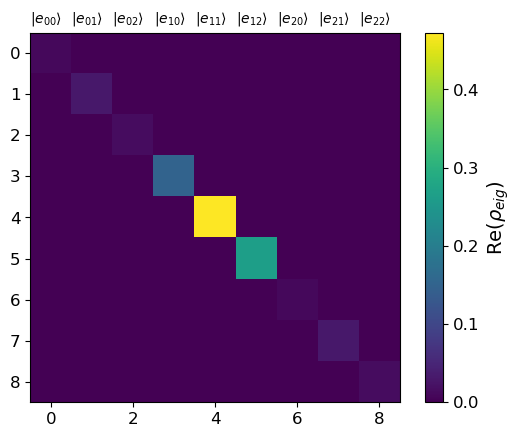

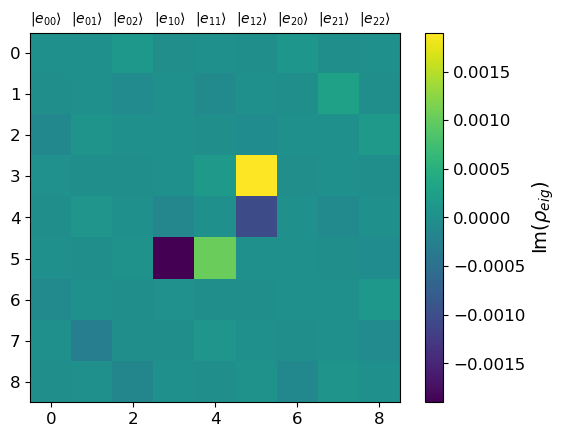

In [59]:
# Generate labels for trying to keep track of the eigenstates
labels = [["$|e_{" + str(j) + str(i) + "}\\rangle$" for i in range(3)] for j in range(3)]

# Now plot the real and imaginary parts of the density matrix in the eigenbasis
plt.figure(1)
plt.imshow(ρ_eig_ss.full().real)
plt.colorbar(label='$\\mathrm{Re}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        plt.text(-0.5 + count, -0.75, labels[i][j], size=10)
        count += 1

plt.figure(2)
plt.imshow(ρ_eig_ss.full().imag)
plt.colorbar(label='$\\mathrm{Im}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        plt.text(-0.5 + count, -0.75, labels[i][j], size=10)
        count += 1

plt.show()

### 3 atoms
Let's see if the code we have so far can handle 3 atoms or if something goes wrong.

In [60]:
# Define velocities
vels = np.array([0, 10, 20])

In [61]:
# Create list of Hamiltonians
H_list = create_Hamiltonians(g10, g21, vels)

In [62]:
# Get the total Hamiltonian
H = get_full_Hamiltonian(H_list)

In [63]:
# Calculate the matrix that changes into Hamiltonian eigenbasis
U = create_cob_matrix(H_list)

In [64]:
# Check that this diagonalizes the full hamiltonian
U.dag() @ H @ U

Quantum object: dims=[[3, 3, 3], [3, 3, 3]], shape=(27, 27), type='oper', dtype=Dense, isherm=True
Qobj data =
[[-1.84195120e+02 -1.01550478e-13  2.65911413e-14 -6.81665156e-14
  -8.38066320e-16 -1.11053612e-15 -7.77245397e-15  1.18953533e-15
  -3.63357057e-15 -1.77347895e-14  1.63675070e-15 -8.33307146e-16
   1.20745350e-16 -6.03917193e-16 -2.85791567e-17 -1.98241015e-15
  -2.16571635e-15  1.65754427e-15 -2.94996440e-14 -5.58559072e-15
  -5.44034654e-15  5.16365286e-15 -5.78089623e-16  2.97208541e-15
  -2.29694201e-15  3.71985305e-15  1.41180375e-15]
 [-9.66434991e-14 -1.68091512e+02 -1.19017132e-14 -2.41657048e-15
  -7.77782846e-14  2.16692903e-15  2.61187942e-15 -2.43480230e-14
  -3.93924715e-15  9.78167105e-16 -2.05738837e-14  4.97145798e-16
   2.19881520e-17  4.44975654e-16 -2.00563610e-16  5.63960802e-16
  -1.06846314e-15 -2.76846123e-16 -1.11200302e-14 -3.64335976e-14
   2.41182385e-15  7.60944441e-17 -4.94018095e-15 -2.22979429e-15
  -4.39899429e-16 -8.59786802e-15  6.44134647e

In [65]:
# Define the collapse operators
σ10_list = get_collapse_ops(3, γ10, σ10)
σ21_list = get_collapse_ops(3, γ21, σ21)

In [66]:
# Calculate the steady state density matrix in the atomic energy level basis
ρ_ss = qu.steadystate(H, [*σ10_list, *σ21_list])

In [67]:
# Transform the density matrix to the eigenbasis of H
ρ_eig_ss = U.dag() * ρ_ss * U
ρ_eig_ss

Quantum object: dims=[[3, 3, 3], [3, 3, 3]], shape=(27, 27), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.51651576e-03-1.56288175e-21j -6.55640312e-08+8.23635599e-07j
   9.24730028e-08+1.81455563e-05j -4.03656978e-08+1.37762545e-06j
  -7.46457652e-10-8.14823789e-11j -1.64861544e-08-3.98983565e-10j
   9.60813875e-08+1.90467232e-05j -1.03486288e-08-7.71270510e-10j
  -2.27893776e-07+2.31105936e-09j -4.05480305e-08-4.13003621e-06j
   2.24481897e-09+1.56533174e-10j  4.94146232e-08-7.37007443e-10j
   3.75286554e-09+7.30963711e-11j -2.01946488e-13+2.03505602e-12j
  -6.45777362e-13+4.49085928e-11j  5.18687392e-08-7.70929491e-10j
  -1.82375870e-12+2.82037860e-11j  1.23872061e-11+6.20577680e-10j
   7.00879263e-08+1.42966215e-05j -7.76767509e-09-5.80025123e-10j
  -1.71059000e-07+1.71039167e-09j -1.29891290e-08-3.16869902e-10j
   7.33671239e-13-7.04083006e-12j  2.99940515e-12-1.55438060e-10j
  -1.79554387e-07+1.78605764e-09j  6.79271220e-12-9.75950871e-11j
  -3.23194360e-11-2.14831205e-0

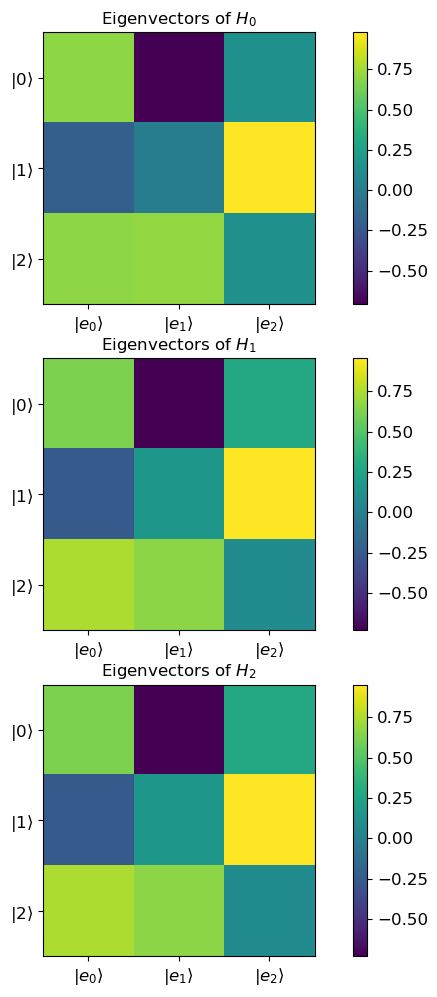

In [68]:
# Let's also plot the two sets of eigenvectors for completeness
# First get eigenvectors of each Hamiltonian into 2d arrays
H0_eigs = np.array([_.full() for _ in H_list[0].eigenstates()[1]])
H1_eigs = np.array([_.full() for _ in H_list[1].eigenstates()[1]])
H2_eigs = np.array([_.full() for _ in H_list[2].eigenstates()[1]])

# Now plot
fig = plt.figure(1, figsize=(10, 12))
ax = fig.subplots(3, 1)
h0 = ax[0].imshow(H0_eigs.real)
ax[0].set_title("Eigenvectors of $H_0$")
ax[0].set_xticks([0, 1, 2])
ax[0].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[0].set_yticks([0, 1, 2])
ax[0].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h0)

h1 = ax[1].imshow(H1_eigs.real)
ax[1].set_title("Eigenvectors of $H_1$")
ax[1].set_xticks([0, 1, 2])
ax[1].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[1].set_yticks([0, 1, 2])
ax[1].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h1)

h2 = ax[2].imshow(H1_eigs.real)
ax[2].set_title("Eigenvectors of $H_2$")
ax[2].set_xticks([0, 1, 2])
ax[2].set_xticklabels(["$|e_0\\rangle$", "$|e_1\\rangle$", "$|e_2\\rangle$"])
ax[2].set_yticks([0, 1, 2])
ax[2].set_yticklabels(["$|0\\rangle$", "$|1\\rangle$", "$|2\\rangle$"])
fig.colorbar(h2)

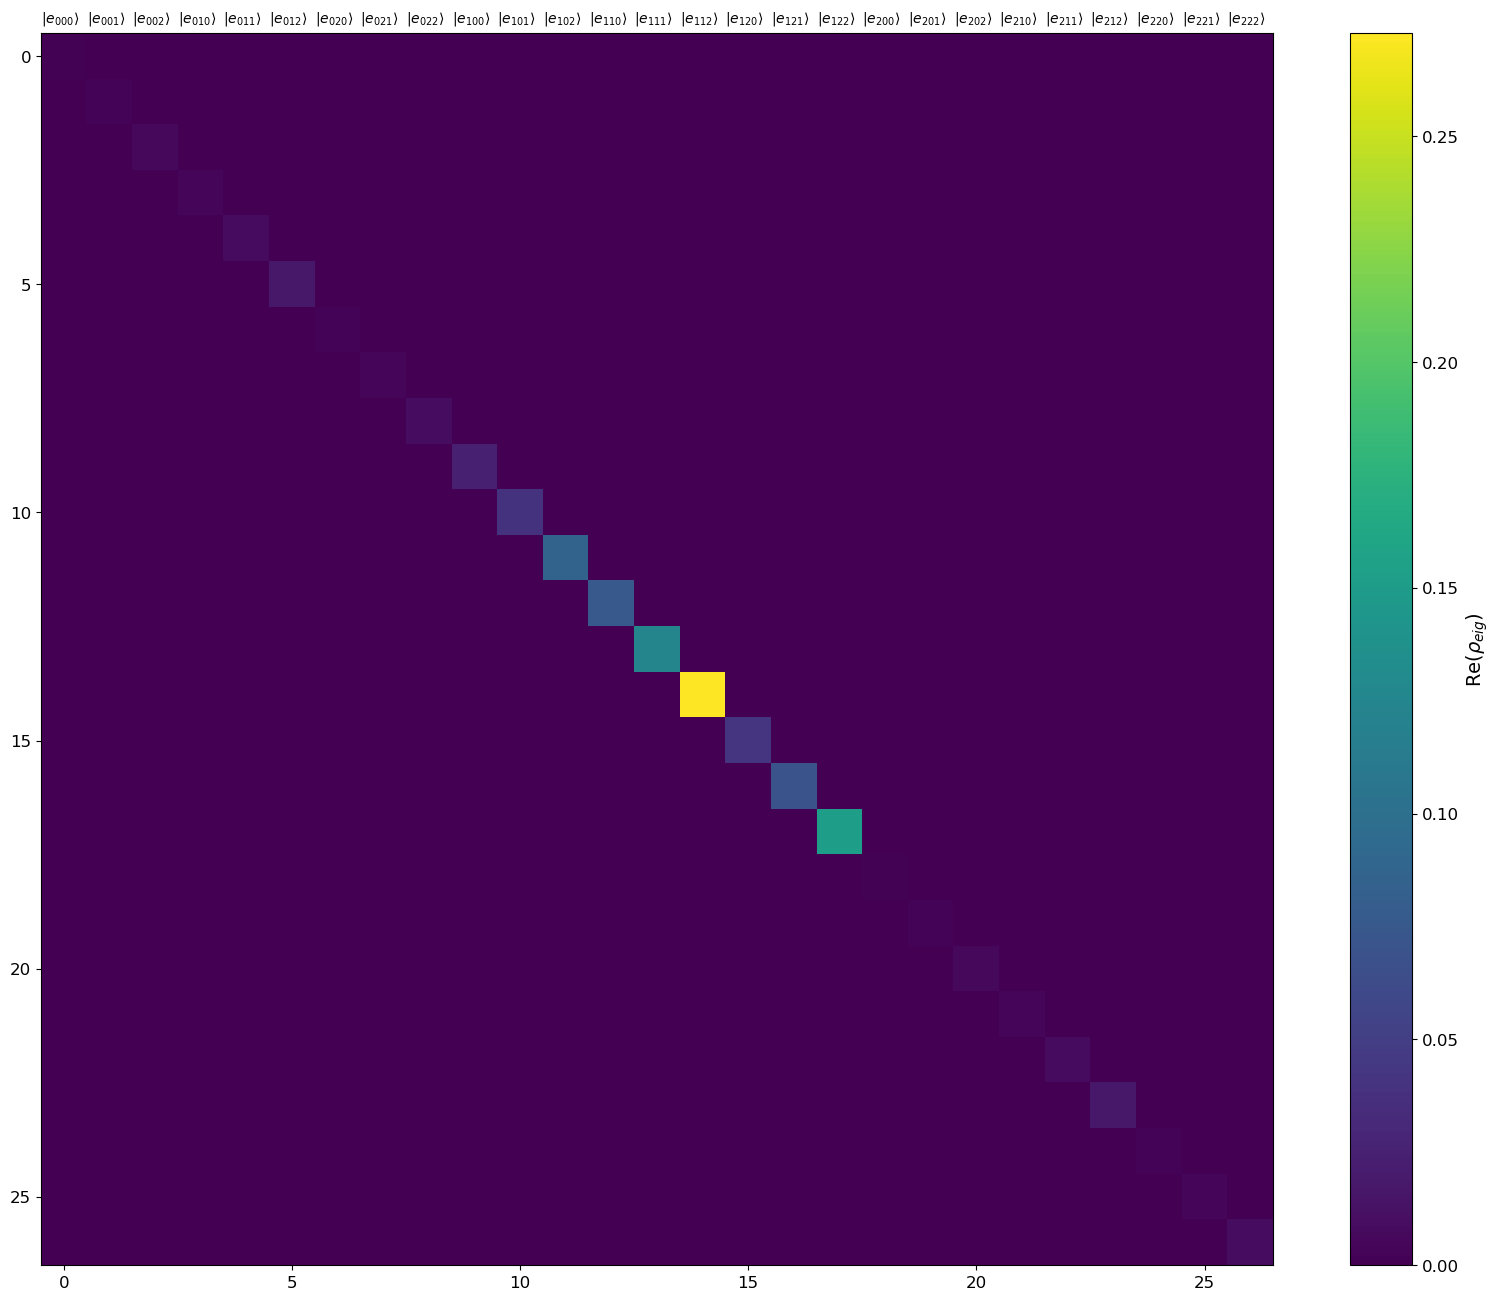

In [69]:
# Generate labels for trying to keep track of the eigenstates
labels = [[["$|e_{" + str(k) + str(j) + str(i) + "}\\rangle$" for i in range(3)] for j in range(3)] for k in range(3)]

# Now plot the real and imaginary parts of the density matrix in the eigenbasis
plt.figure(1, figsize=(20, 16))
plt.imshow(ρ_eig_ss.full().real)
plt.colorbar(label='$\\mathrm{Re}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        for k in range(3):
            plt.text(-0.5 + count, -0.75, labels[i][j][k], size=10)
            count += 1

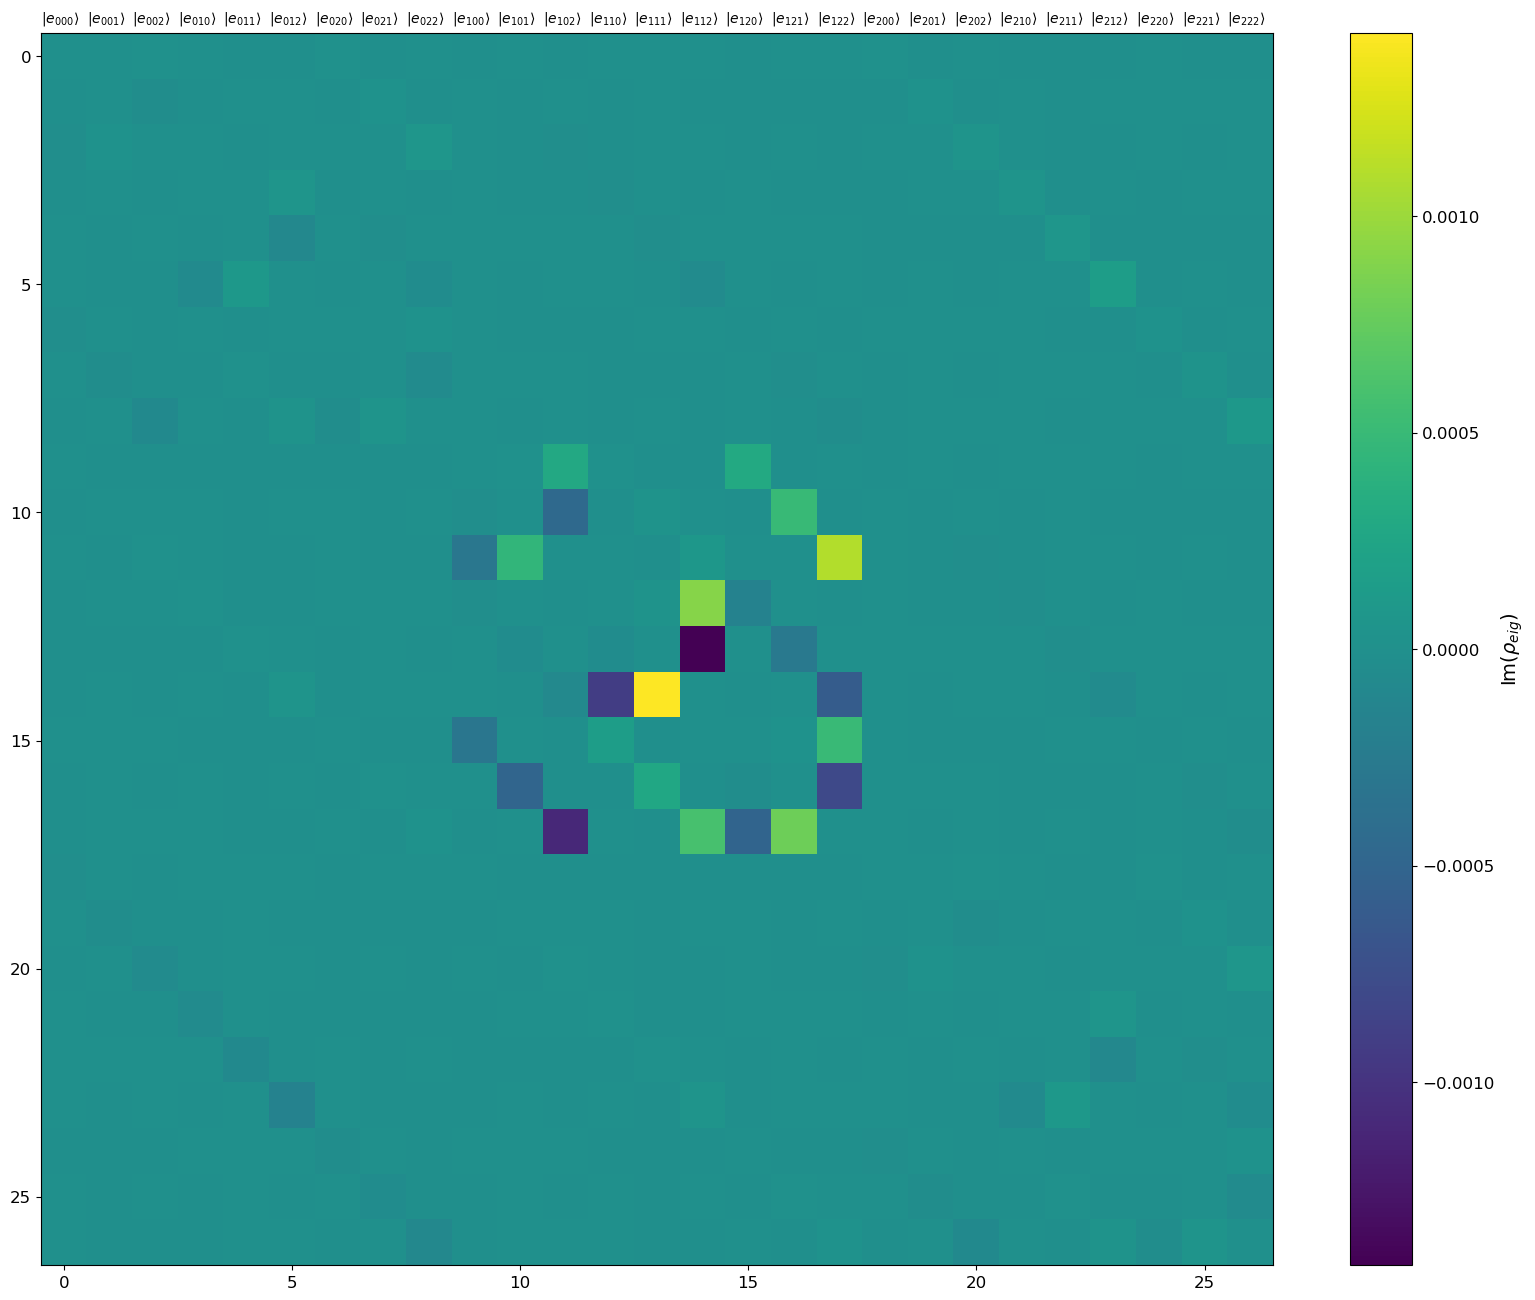

In [70]:
plt.figure(2, figsize=(20, 16))
plt.imshow(ρ_eig_ss.full().imag)
plt.colorbar(label='$\\mathrm{Im}(\\rho_{eig})$')
count = 0
for i in range(3):
    for j in range(3):
        for k in range(3):
            plt.text(-0.5 + count, -0.75, labels[i][j][k], size=10)
            count += 1

plt.show()